In [1]:
from dlfs.base import Module, Loss, Optimizer, Layer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer, ConvLayer, ConvTransposeLayer, BatchNorm2D
from dlfs.activation import SiLU

from dlfs.loss import MSE_Loss
from dlfs.optimizers import Optimizer_Adam, Optimizer_AdamW
from dlfs.helpers import get_random_batch, DLFSData

import numpy as np
import matplotlib.pyplot as plt

# Diffusion - overview

- in physics, a phenomenon in which particles spontaneously spread from high density to low density regions until equilibrium is reached

- example: dropping ink in water (image source: https://www.flowillustrator.com/fluid-dynamics/basics/viscosity-as-diffusion.php)

<img src="../../img/diff1.png" alt="diff1" width="400" style="padding: 30px;"/>

- in deep learning we take our original data $x_0$ as the start of the diffusion process at time $t=0$ and we gradually corrupt data until it is complete Gaussian noise

<img src="../../img/diff2.png" alt="diff2" width="400" style="padding: 30px;"/>

(image source: https://developer.nvidia.com/blog/improving-diffusion-models-as-an-alternative-to-gans-part-1/)
- a neural network is trained to reverse the diffusion process which leads to new sample generation

***

# Diffusion - deep learning approach

### 1. Forward diffusion

Taking real uncorrupted data $x_o$ we gradually add noise through $T$ timesteps, $1 \leq t \leq T$ such that

$$ x_t = \sqrt{1 - \beta_t}x_{t-1} + \sqrt{\beta_t} \epsilon_t $$

where $\beta_t$ is noise controlling constant (variance) at timestep $t$ and $\epsilon_t$ is Gaussian noise, $\epsilon_t \sim \mathcal{N}(0, 1)$.

Forward diffusion process can also be written without the recursive formulation

$$ x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon $$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha_t} = \Pi_{s=1}^{t} \alpha_s$. This simplification is possible due to the fact that linear combination of Gaussians is also Gaussian.

### 2. Reverse diffusion

From pure Gaussian noise we aim to undo all the noise applied during forward process and return to original data. We are interested in the distribution

$$ p_{\theta} (x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_{\theta}(x_t, t), \beta_t I) $$

Using the noisy $x_t$ we sample from this distribution to obtain a slightly less noisy sample $x_{t-1}$. We use a neural network to learn to predict noise $\epsilon_{\theta}$ for sample $x_t$ at timestep $t$ so we can calculate $\mu_{\theta}(x_t, t)$.

$$ \mu_{\theta}(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha_t}}} \epsilon_{\theta}(x_t, t) \right)$$

Using the calculated mean we sample from $p_{\theta}$ to obtain a new less noisy sample.

$$ x_{t-1} = \mu_{\theta}(x_t, t) + \sqrt{\beta_t} z \quad \quad z \sim \mathcal{N}(0, 1)$$

# 3. Training objective

Training objective of the network is to predict noise $\epsilon_{\theta}(x_t, t)$ for noisy sample $x_t$ at timestep $t$. During forward diffusion noise is added to sample and this is the noise we would like to estimate.

The loss function used is MSE between the added noise at timestep $t$, $\epsilon_t$ and predicted noise $\epsilon_{\theta}(x_t, t)$.

$$ \mathcal{L} = || \epsilon_{\theta}(x_t, t) - \epsilon_t ||^2 = \text{MSE}(\epsilon_{\theta}(x_t, t), \epsilon_t) $$

***

# U-Net block for upsampling/downsampling

In [2]:
class Block(Module):

    def __init__(self, input_channels: int, output_channels: int, time_emb_dim: int, up: bool = False) -> None:
        """
        UNet single block. Consists of convolutional layers for feature extraction and time embedding dense layer for injecting time information.

        Parameters
        ----------
        input_channels : int
            Input image number of channels.

        output_channels : int
            Output image number of channels.

        time_emb_dim : int
            Time embedding vector dimension.

        up : bool, default=False
            Whether block is used for downsampling (encoder) or upsampling (decoder). 
        """

        self.time_mlp = DenseLayer(time_emb_dim, output_channels)

        if up:
            self.conv1 = ConvLayer(2*input_channels, output_channels, kernel_size=3, padding=1)
            self.transform = ConvTransposeLayer(output_channels, output_channels, kernel_size=4, stride=2, padding=1)
        else:
            self.conv1 = ConvLayer(input_channels, output_channels, kernel_size=3, padding=1)
            self.transform = ConvLayer(output_channels, output_channels, kernel_size=4, stride=2, padding=1)

        self.conv2 = ConvLayer(input_channels=output_channels, 
                               output_channels=output_channels, 
                               kernel_size=3, 
                               stride=1, 
                               padding=1)

        self.bnorm1 = BatchNorm2D(output_channels)
        self.bnorm2 = BatchNorm2D(output_channels)

        self.silu1 = SiLU()
        self.silu2 = SiLU()
        self.silu3 = SiLU()

    def forward(self, x: np.ndarray, t: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the UNet block. Creates output attribute.

        Parameters
        ----------
        x : np.ndarray
            Input images array of shape (B, C_in, H, W).

        t : np.ndarray
            Array of timestep embeddings of shape (B, time_emb_dim).

        training : bool, default=False
            Flag indicating whether module is in training mode, used for API consistency.

        Returns
        -------
        None
        """

        self.conv1.forward(x)
        self.silu1.forward(self.conv1.output)
        self.bnorm1.forward(self.silu1.output)

        h = self.bnorm1.output.copy()

        self.time_mlp.forward(t)
        self.silu2.forward(self.time_mlp.output)

        time_emb = self.silu2.output[(..., ) + (None, ) * 2].copy()

        new = h + time_emb

        self.conv2.forward(new)
        self.silu3.forward(self.conv2.output)
        self.bnorm2.forward(self.silu3.output)

        self.transform.forward(self.bnorm2.output)

        self.output = self.transform.output

    def backward(self, delta: np.ndarray) -> None:
        """
        Backward pass for the UNet block. Creates gradient attribute.

        Parameters
        ----------
        delta : np.ndarray
            Upstream gradient of shape (B, C_out, H, W).

        Returns
        -------
        None
        """

        self.transform.backward(delta)

        self.bnorm2.backward(self.transform.dinputs)
        self.silu3.backward(self.bnorm2.dinputs)
        self.conv2.backward(self.silu3.dinputs)

        dh = self.conv2.dinputs.copy()
        dtime_emb = self.conv2.dinputs.copy()

        dtime_emb = np.sum(dtime_emb, axis=(2,3))

        self.silu2.backward(dtime_emb)
        self.time_mlp.backward(self.silu2.dinputs)
        self.dt = self.time_mlp.dinputs

        self.bnorm1.backward(dh)
        self.silu1.backward(self.bnorm1.dinputs)
        self.conv1.backward(self.silu1.dinputs)

        self.dinputs = self.conv1.dinputs

# U-Net

In [3]:
class UNet(Module):

    def __init__(self, input_channels: int = 1, output_channels: int = 1, time_emb_dim: int = 32, down_channels: tuple = (16,32,64)) -> None:
        """
        UNet module. Consists of downsampling blocks, bottleneck and upsampling blocks.

        Parameters
        ----------
        input_channels : int, default=1
            Input image number of channels.

        output_channels : int, default=1
            Output image number of channels.

        time_emb_dim : int, default=32
            Time embedding vector dimension.

        down_channels : tuple, default=(16, 32, 64)
            Number of output channels associated with each downsampling block respectively. Upsampling output channels are in reverse order.
        """
        self.time_emb_dim = time_emb_dim

        # Reverse downsampling channels for upsampling blocks
        up_channels = tuple(reversed(down_channels))

        self.conv0 = ConvLayer(input_channels, down_channels[0], kernel_size=3, stride=1, padding=1)

        # Create downsampling blocks
        self.downs = [
            Block(down_channels[i], down_channels[i + 1], time_emb_dim=time_emb_dim) for i in range(len(down_channels) - 1) 
        ]

        # Create bottleneck
        self.bottleneck = SequentialWrapper(
            [ConvLayer(down_channels[-1], down_channels[-1], kernel_size=1, stride=1, padding=0),
             SiLU(),
             ConvLayer(down_channels[-1], down_channels[-1], kernel_size=1, stride=1, padding=0),
             SiLU()]
        )

        # Create upsampling blocks
        self.ups = [
            Block(up_channels[i], up_channels[i + 1], time_emb_dim=time_emb_dim, up=True) for i in range(len(up_channels) - 1) 
        ]

        self.conv_last = ConvLayer(up_channels[-1], output_channels, kernel_size=1, stride=1, padding=0)

        self.time_mlp = SequentialWrapper(
            [DenseLayer(time_emb_dim, time_emb_dim),
             SiLU()]
        )

    def timestep_embedding(self, t: np.ndarray, dim: int) -> np.ndarray:
        """
        Helper method for sinusoidal timestep embedding.

        Parameters
        ----------
        t : np.ndarray
            Array of timestep scalars.

        dim : int
            Embedding dimension.

        Returns
        -------
        embeddings : np.ndarray
            Embedding array of shape (B, dim)
        """

        # Reshape to (B, 1)
        t = np.asarray(t).reshape(-1, 1)
        half_dim = dim // 2

        i = np.arange(half_dim, dtype=np.float32) # (half_dim, )
        freqs = np.exp(-np.log(10000) * (2 * i / dim)) # (half_dim,)
        args = t * freqs # (B, half_dim)

        return np.concatenate([np.sin(args), np.cos(args)], axis=-1) # (B, dim)

    def forward(self, x: np.ndarray, t: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the UNet. Creates output attribute.

        Parameters
        ----------
        x : np.ndarray
            Input images array of shape (B, C_in, H, W).

        t : np.ndarray
            Array of timestep scalars of shape (B, ).

        training : bool, default=False
            Flag indicating whether module is in training mode, used for API consistency.

        Returns
        -------
        None
        """

        # Emebed timesteps
        t_emb = self.timestep_embedding(t, self.time_emb_dim)
        self.time_mlp.forward(t_emb)
        t_emb = self.time_mlp.output # (B, time_emb_dim)

        self.conv0.forward(x)
        x_down = self.conv0.output

        self.residual_inputs = []

        # Downsample by forwarding through all down blocks
        for d in self.downs:
            d.forward(x_down, t_emb)
            self.residual_inputs.append(d.output.copy())
            x_down = d.output.copy()

        self.bottleneck.forward(self.downs[-1].output)

        # Upsample by forwarding through all up blocks
        x_up = self.bottleneck.output
        for idx, u in enumerate(self.ups):
            res_x = self.residual_inputs[-1-idx]
            combined = np.concatenate((x_up, res_x), axis=1)
            u.forward(combined, t_emb)
            x_up = u.output.copy()

        self.conv_last.forward(self.ups[-1].output)

        self.output = self.conv_last.output

    def backward(self, delta: np.ndarray) -> None:
        """
        Backward pass for the UNet. Creates gradient attributes.

        Parameters
        ----------
        delta : np.ndarray
            Upstream gradient of shape (B, C_out, H, W).

        Returns
        -------
        None
        """

        self.conv_last.backward(delta)
        grad = self.conv_last.dinputs

        d_t_emb_total = np.zeros_like(self.time_mlp.output)

        residual_stack = list(reversed(self.residual_inputs))

        for u in reversed(self.ups):
            u.backward(grad)

            B, C, H, W = u.dinputs.shape

            skip = residual_stack.pop()
            skip_c = skip.shape[1]
            main_c = u.dinputs.shape[1] - skip_c

            grad_main = u.dinputs[:, :main_c]

            grad = grad_main

            d_t_emb_total += u.dt

        self.bottleneck.backward(grad)
        grad = self.bottleneck.dinputs

        for d in reversed(self.downs):

            d.backward(grad)

            grad = d.dinputs

            d_t_emb_total += d.dt

        self.conv0.backward(grad)
        grad_x0 = self.conv0.dinputs

        self.time_mlp.backward(d_t_emb_total)
        d_t_emb = self.time_mlp.dinputs    

        self.dinputs = grad_x0
        self.dinputs_t = d_t_emb

# Diffusion model

In [4]:
class Diffusion(Module):

    def __init__(self, model: Module, 
                       image_channels: int = 1, 
                       image_size: int = 28, 
                       t_emb_dim: int = 128, 
                       timesteps: int = 1000, 
                       loss_function: Loss = None, 
                       optimizer: Optimizer = None) -> None:
        """
        Diffusion model similar to original DDPM paper.

        Parameters
        ----------
        model : Module
            Neural network model which predicts the noise from image, usually UNet.

        image_channels : int, default=1
            Input image number of channels.

        image_size: int, default=28
            Image height and width, assumes square image.

        t_emb_dim : int, default=128
            Time embedding vector dimension.

        timesteps : int, default=1000
            Number of steps in forward and reverse diffusion.

        loss_function : Loss, default=None
            The loss function used during training.

        optimizer : Optimizer, default=None
            The optimizer used for training.
        """
        # Model used to predict noise
        self.model = model

        # Image pattributes
        self.image_channels = image_channels
        self.image_size = image_size

        # Time related attributes
        self.t_emb_dim = t_emb_dim
        self.timesteps = timesteps

        # Beta noise schedule, signal retention constants
        self.betas = np.linspace(1e-4, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)
        self.ac = np.sqrt(self.alphas_cumprod)
        self.om = np.sqrt(1 - self.alphas_cumprod)

        self.loss_function = loss_function
        self.optimizer = optimizer

    def forward_diffusion(self, x0: np.ndarray, t: np.ndarray) -> np.ndarray:
        """
        Helper method for forward diffusion.

        Parameters
        ----------
        x0 : np.ndarray
            Original uncorrupted samples of shape (B, C, H, W).

        t : np.ndarray
            Array of scalar timesteps of shape (B, ).

        Returns
        -------
        x_t : np.ndarray
            Corrupted samples at timestep t of shape (B, C, H, W).
        """

        # Get scales for original image (ac_t) and noise (om_t), reshape to match image shape
        ac_t = self.ac[t].reshape(-1, 1, 1, 1)
        om_t = self.om[t].reshape(-1, 1, 1, 1)

        # Sample noise
        noise = np.random.randn(*x0.shape)

        # Forward diffusion
        x_t = ac_t * x0 + om_t * noise

        return x_t, noise

    def forward(self, x: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for Diffusion. Creates output attribute.

        Parameters
        ----------
        x : np.ndarray
            Input images array of shape (B, C_in, H, W).

        training : bool, default=False
            Flag indicating whether module is in training mode, used for API consistency.

        Returns
        -------
        None
        """

        # Extract batch size and number of channels (images only)
        B, C = x.shape[:2]

        # Create random timesteps
        t = np.random.randint(1, self.timesteps, size=(B, ))

        # Create noisy samples x_t for each timestep t
        x_t, noise = self.forward_diffusion(x, t)

        # Pass noisy data and timesteps through network to predict noise
        self.model.forward(x_t, t, training=training)

        # Model output is the predicted noise
        self.output = self.model.output

        # True noise is the noise added during forward diffusion step
        self.noise_output = noise

    def backward(self, predicted: np.ndarray, true: np.ndarray) -> None:
        """
        Backward pass for Diffusion.

        Parameters
        ----------
        predicted : np.ndarray
            Predicted noise by the model of shape (B, C, H, W).

        true : np.ndarray
            True noise added during forward diffusion of shape (B, C, H, W).

        Returns
        -------
        None
        """
        # Compare predicted noise and true noise
        self.loss_function.backward(predicted, true)
        # Backprop through model
        self.model.backward(self.loss_function.dinputs)

    def print_grads(self, layer):

        if isinstance(layer, Layer):
            params = layer.get_parameters()
            if params is None:
                return

            for name in params:
                param = getattr(layer, 'd'+name)
                print(f'{layer.__class__.__name__} grad {name}: {np.linalg.norm(param)}')

        if isinstance(layer, list):
            for l in layer:
                self.print_grads(l)

        if isinstance(layer, Module):
            for name, attr in vars(layer).items():
                self.print_grads(attr)

    def train(self, X: np.ndarray, epochs: int = 1000, batch_size: int = None, print_every: int = None) -> None:
        """
        Train the Diffusion model for a specified number of epochs.

        Parameters
        ----------
        X : np.ndarray
            Input image data of shape (n_samples, C, H, W).

        epochs : int, default=1000
            The number of epochs to train the model.

        batch_size : int, default=None
            The size of the batch to use for each training step. If `None`, the entire dataset is used
            for each forward/backward pass.

        print_every : int, default=None
            If provided, will print the current loss value every 
            `print_every` epochs.

        Returns
        -------
        None
        """

        # Store loss values for plotting
        self.loss_vals = []
        self.std_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:
                batch_X = get_random_batch(X, batch_size=batch_size)[0]
            else:
                # If batch size is not specified take the whole dataset
                batch_X = X

            # Forward pass
            self.forward(batch_X, training=True)

            # Backward pass
            self.backward(self.output, self.noise_output)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            # Store current loss and std of output
            loss = self.loss_function.calculate(self.output, self.noise_output)
            self.loss_vals.append(loss)
            self.std_vals.append(np.std(self.output))

            if print_every is not None and not i % print_every:
                print(f'===== EPOCH : {i} ===== LOSS : {loss:.5f} ===== OUTPUT STD: {np.std(self.output):.5f} =====')

    def generate(self, n_samples: int = 10, print_every: int = 100) -> np.ndarray:
        """
        Generate new samples using reverse diffusion.

        Parameters
        ----------
        n_samples : int, default=10
            Number of samples to generate.

        print_every : int, default=10
            If provided, will print the current timestep of generation every 
            `print_every` steps.

        Returns
        -------
        generated_images : np.ndarray
            Array of generated images of shape (n_samples, C, H, W).
        """

        # Get batch size, number of channels, width and height of images to produce
        B, C, H, W = n_samples, self.image_channels, self.image_size, self.image_size
        
        # Start from pure Gaussian noise
        x_t = np.random.randn(B, C, H, W).astype(np.float32)

        # In reverse order start denoising
        for t in reversed(range(self.timesteps)):

            if not t % print_every:
                print(f'Generation at timestep {t}')

            # Create array for current timestep
            t_arr = np.array([t] * B)
              
            # Predict noise for current x_t and current timestep
            self.model.forward(x_t, t_arr, training=False)
            epsilon_pred = self.model.output
            
            # Get signal scaling constants (alphas) and variance (beta) for current timestep
            # Reshape to match image dimensions
            alpha_t = self.alphas[t_arr].reshape(B, 1, 1, 1)
            alpha_cumprod_t = self.alphas_cumprod[t_arr].reshape(B, 1, 1, 1)
            beta_t = self.betas[t_arr].reshape(B, 1, 1, 1)
            
            # Calculate mean
            mean = (1 / np.sqrt(alpha_t)) * (x_t - ((beta_t) / np.sqrt(1 - alpha_cumprod_t)) * epsilon_pred)
            
            if t > 0:
                noise = np.random.randn(*x_t.shape)
                # Sample using mean and some noise to obtain a new less noisy sample
                x_t = mean + np.sqrt(beta_t) * noise
            else:
                x_t = mean

        generated_images = x_t

        return generated_images

# Load data

In [5]:
mnist_path = "../data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [6]:
np.random.seed(1) # set seed for reproducilibilty

X_train, _ = DLFSData.select_MNIST_labels(X_train, y_train, labels=[0, 1, 2, 3], limit=50)
X_train = DLFSData.normalize_MNIST(X_train, range=(-1, 1))
X_train = np.expand_dims(X_train, axis=1)

print(f'X_train: {X_train.shape}')

X_train: (200, 1, 28, 28)


In [7]:
lr=2e-4
epochs=1000
batch_size = 32

loss = MSE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr)

unet = UNet(input_channels=1, output_channels=1, time_emb_dim=64, down_channels=(32, 64, 128))

diffusion = Diffusion(model=unet, image_channels=1, timesteps=1000, loss_function=loss, optimizer=optimizer)

diffusion.train(X_train, print_every=10, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 0.50387 ===== OUTPUT STD: 0.16842 =====
===== EPOCH : 100 ===== LOSS : 0.11746 ===== OUTPUT STD: 0.86856 =====
===== EPOCH : 200 ===== LOSS : 0.08082 ===== OUTPUT STD: 0.91346 =====
===== EPOCH : 300 ===== LOSS : 0.05462 ===== OUTPUT STD: 0.91480 =====
===== EPOCH : 400 ===== LOSS : 0.07130 ===== OUTPUT STD: 0.89961 =====
===== EPOCH : 500 ===== LOSS : 0.04178 ===== OUTPUT STD: 0.97422 =====
===== EPOCH : 600 ===== LOSS : 0.06716 ===== OUTPUT STD: 0.92625 =====
===== EPOCH : 700 ===== LOSS : 0.04364 ===== OUTPUT STD: 0.98926 =====
===== EPOCH : 800 ===== LOSS : 0.03271 ===== OUTPUT STD: 0.99421 =====
===== EPOCH : 900 ===== LOSS : 0.03262 ===== OUTPUT STD: 0.99295 =====
===== EPOCH : 1000 ===== LOSS : 0.04041 ===== OUTPUT STD: 0.96928 =====


# Loss and STD

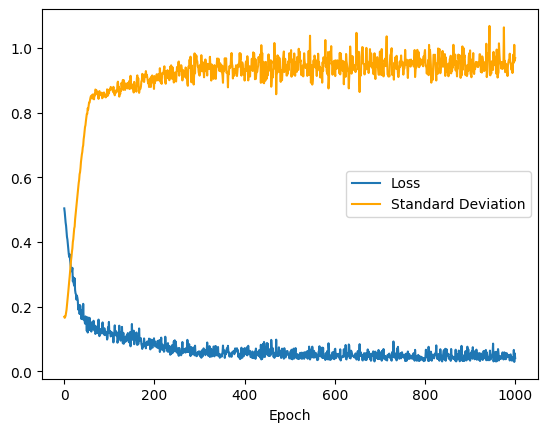

In [8]:
plt.plot(range(len(diffusion.loss_vals)), diffusion.loss_vals, label='Loss')
plt.plot(range(len(diffusion.std_vals)), diffusion.std_vals, color='orange', label='Standard Deviation')
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Generating new samples

In [9]:
new_images = diffusion.generate(n_samples=50)

Generation at timestep 900
Generation at timestep 800
Generation at timestep 700
Generation at timestep 600
Generation at timestep 500
Generation at timestep 400
Generation at timestep 300
Generation at timestep 200
Generation at timestep 100
Generation at timestep 0


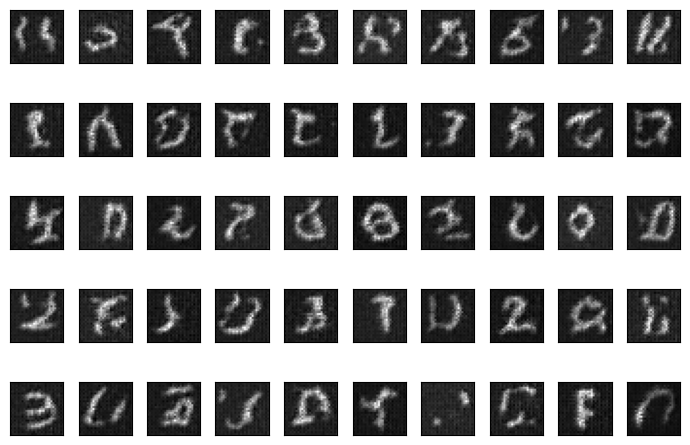

In [10]:
fig, ax = plt.subplots(nrows=5, ncols=10, figsize=(7, 5))
ax = ax.flatten()

for idx, x in enumerate(new_images):

    img = x.reshape(28, 28)

    ax[idx].imshow(img, cmap='gray')
    ax[idx].set_xticks([])
    ax[idx].set_yticks([])

plt.tight_layout()
plt.show()

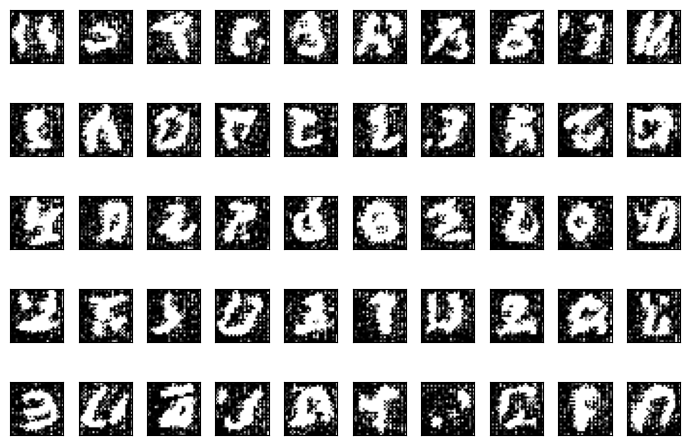

In [11]:
fig, ax = plt.subplots(nrows=5, ncols=10, figsize=(7, 5))
ax = ax.flatten()
images = DLFSData.denormalize_MNIST(new_images, range=(-1, 1))

for idx, x in enumerate(images):

    img = x.reshape(28, 28)

    ax[idx].imshow(img, cmap='gray')
    ax[idx].set_xticks([])
    ax[idx].set_yticks([])

plt.tight_layout()
plt.show()

# Takeaways and observations

- training is stable if standard deviation of model output is growing towards 1 and mean of model output is around 0

- UNet number of channels plays a big role in generation, in this example (32, 64, 128) is needed to produce recognizable images 